Scale factor: 4
Original image size: (385, 632)
Zoomed image size: (1540, 2528)
Nearest-neighbor SSD: 0.0
Bilinear SSD: 0.009342166703654247


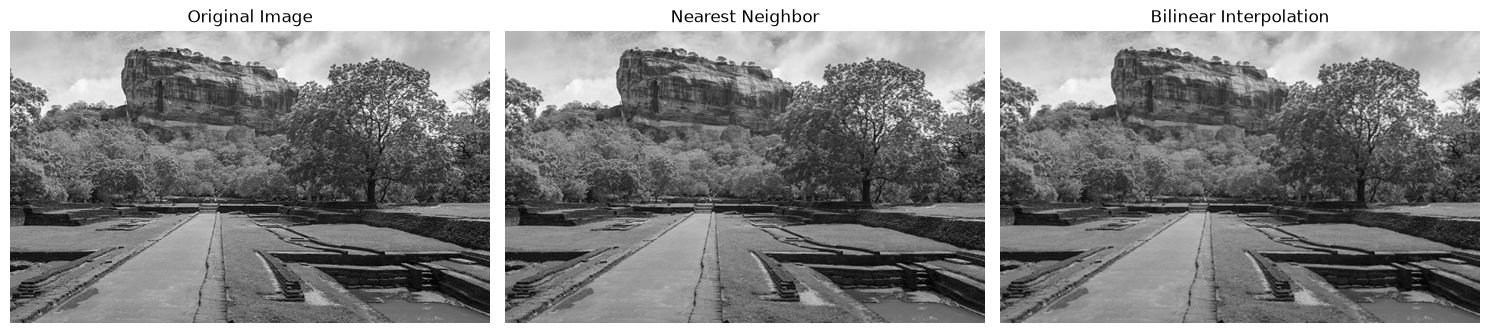

In [11]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


def zoom_nearest(image, scale_factor):
    height, width = image.shape[:2]

    new_height = int(round(height * scale_factor))
    new_width = int(round(width * scale_factor))

    zoomed_image = np.zeros(
        (new_height, new_width),
        dtype=image.dtype
    )

    for i in range(new_height):
        for j in range(new_width):
            source_y = min(int(i / scale_factor), height - 1)
            source_x = min(int(j / scale_factor), width - 1)

            zoomed_image[i, j] = image[source_y, source_x]

    return zoomed_image


def zoom_bilinear(image, scale_factor):
    height, width = image.shape[:2]

    new_height = int(round(height * scale_factor))
    new_width = int(round(width * scale_factor))

    zoomed_image = np.zeros(
        (new_height, new_width),
        dtype=np.float32
    )

    for i in range(new_height):
        for j in range(new_width):
            source_y = i / scale_factor
            source_x = j / scale_factor

            y0 = int(np.floor(source_y))
            x0 = int(np.floor(source_x))

            y1 = min(y0 + 1, height - 1)
            x1 = min(x0 + 1, width - 1)

            dy = source_y - y0
            dx = source_x - x0

            top_left = image[y0, x0]
            top_right = image[y0, x1]
            bottom_left = image[y1, x0]
            bottom_right = image[y1, x1]

            top = (
                top_left * (1 - dx)
                + top_right * dx
            )

            bottom = (
                bottom_left * (1 - dx)
                + bottom_right * dx
            )

            zoomed_image[i, j] = (
                top * (1 - dy)
                + bottom * dy
            )

    return np.clip(
        zoomed_image,
        0,
        255
    ).astype(image.dtype)


def normalized_ssd(original, reconstructed):
    original = original.astype(np.float64)
    reconstructed = reconstructed.astype(np.float64)

    numerator = np.sum(
        (original - reconstructed) ** 2
    )

    denominator = np.sum(
        original ** 2
    )

    if denominator == 0:
        return 0

    return numerator / denominator


def display_results(original, nearest_image, bilinear_image):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(nearest_image, cmap="gray")
    plt.title("Nearest Neighbor")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(bilinear_image, cmap="gray")
    plt.title("Bilinear Interpolation")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":

    scale_factor = 4

    image = cv.imread(
        r'D:\Image processing and Computer Vision\Images\sigiriya.jpg',
        cv.IMREAD_GRAYSCALE
    )

    assert image is not None

    nearest_result = zoom_nearest(
        image,
        scale_factor
    )

    bilinear_result = zoom_bilinear(
        image,
        scale_factor
    )

    nearest_reconstructed = cv.resize(
        nearest_result,
        (image.shape[1], image.shape[0]),
        interpolation=cv.INTER_AREA
    )

    bilinear_reconstructed = cv.resize(
        bilinear_result,
        (image.shape[1], image.shape[0]),
        interpolation=cv.INTER_AREA
    )

    nearest_ssd = normalized_ssd(
        image,
        nearest_reconstructed
    )

    bilinear_ssd = normalized_ssd(
        image,
        bilinear_reconstructed
    )

    print("Scale factor:", scale_factor)
    print("Original image size:", image.shape)
    print("Zoomed image size:", nearest_result.shape)
    print("Nearest-neighbor SSD:", nearest_ssd)
    print("Bilinear SSD:", bilinear_ssd)

    display_results(
        image,
        nearest_result,
        bilinear_result
    )